<div style="background: linear-gradient(135deg, #0f172a, #1e293b); color:white; padding:25px; border-radius:10px;
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;">Market Sentiment Analysis from Tweets</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#94a3b8;">
    Transformer Encoders
  </h3>

  <hr style="width:60%; border:1px solid #475569; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Text Mining (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#cbd5e1;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e2e8f0; padding:18px; border-radius:6px;">
This notebook produces sentence-level <b>CLS embeddings</b> from pre-trained Transformer Encoders and feeds them into traditional ML classifiers (LR, SVM, XGBoost).

The encoders are chosen for complementary domain coverage:
<ul>
  <li><b><a href="https://huggingface.co/ProsusAI/finbert" target="_blank">FinBERT</a></b> (<code>ProsusAI/finbert</code>) - BERT-base further pretrained on financial corpora (analyst reports, financial news). Closest to our domain.</li>
  <li><b><a href="https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest" target="_blank">Twitter-RoBERTa</a></b> (<code>cardiffnlp/twitter-roberta-base-sentiment-latest</code>) - RoBERTa-base trained on ~124M tweets, fine-tuned for sentiment. Closest to our text style.</li>
  <li><b><a href="https://huggingface.co/distilbert-base-uncased" target="_blank">DistilBERT</a></b> (<code>distilbert-base-uncased</code>) - distilled BERT-base, 40% smaller, 60% faster, 97% of BERT's performance. Generic baseline.</li>
</ul>
Fine-tuning of these encoders is addressed in the next notebook.
</div>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-setup)
* [2. Load Data](#2-load-data)
* [3. CLS Embedding Extraction](#3-extract)
  * [3.1 FinBERT](#3-1-finbert)
  * [3.2 Twitter-RoBERTa](#3-2-twitter)
  * [3.3 DistilBERT](#3-3-distilbert)
* [4. Classification on CLS Embeddings](#4-classify)
  * [4.1 Logistic Regression](#4-1-lr)
  * [4.2 LinearSVC](#4-2-svm)
  * [4.3 XGBoost](#4-3-xgb)
* [5. Evaluation & Comparison](#5-eval)
* [6. Save Embeddings & Results](#6-save)

<div id="1-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">1. Environment Setup</h2>
</div>

Tokenization and forward passes use **raw text** (not the lemmatized/stemmed variants), because transformer tokenizers are designed for unmodified natural language - their subword vocabulary expects original casing, contractions and punctuation.

In [16]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os


# PROJECT_PATH = '/content/drive/MyDrive/Text-Mining'
# os.chdir(f'{PROJECT_PATH}/notebooks')
# print(f'Working dir: {os.getcwd()}')

In [17]:
# (uncomment as needed)
!pip install -q transformers torch

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')
import os


import torch
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

sns.set_theme(style='whitegrid')
LABEL_NAMES = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
PALETTE     = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
SEED        = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch version : {torch.__version__}')
print('All imports OK')

Device          : cpu
PyTorch version : 2.10.0
All imports OK


<div id="2-load-data" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">2. Load Data</h2>
</div>

Load the raw text splits from notebook 02. Labels are loaded separately. Transformer tokenizers will handle the rest.

In [18]:
with open('../data/processed_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

# Raw text - transformer tokenizers prefer untouched input
x_train_raw = splits['x_train'].reset_index(drop=True)
x_val_raw   = splits['x_val'].reset_index(drop=True)
x_test_raw  = splits['test'].reset_index(drop=True)

# Labels
y_train  = splits['y_train'].reset_index(drop=True).values
y_val    = splits['y_val'].reset_index(drop=True).values
test_ids = splits['test_ids'].reset_index(drop=True).values

print(f'Train : {len(x_train_raw):,} tweets')
print(f'Val   : {len(x_val_raw):,} tweets')
print(f'Test  : {len(x_test_raw):,} tweets')
print(f'\nClass distribution (train):')
print(pd.Series(y_train).map(LABEL_NAMES).value_counts())

# Sanity sample
print(f'\nSample raw tweet: {x_train_raw.iloc[0]!r}')

Train : 7,634 tweets
Val   : 1,909 tweets
Test  : 2,388 tweets

Class distribution (train):
Neutral    4942
Bullish    1538
Bearish    1154
Name: count, dtype: int64

Sample raw tweet: 'Nasdaq prices 600M of 0.875% senior notes'


<div id="3-extract" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">3. CLS Embedding Extraction</h2>
</div>

**What is a CLS embedding?** BERT-style encoders prepend a special `[CLS]` token to every input. After the forward pass, the final-layer hidden state of that token serves as a single-vector summary of the entire sequence - a dense, contextual representation of the tweet's meaning.

**Why not fine-tune?** This notebook treats the transformer as a **frozen feature extractor**: forward pass once, store the 768-dim vector, train a fast classifier in scikit-learn on top. Fine-tuning (updating transformer weights with a classification head) is reserved for the next notebook - it is more expensive and only worthwhile if the pretrained representation underfits the task.

**Why CLS over mean pooling?** Both are common. CLS is the BERT-original recipe and was trained explicitly to summarise the sequence via the NSP task. Mean pooling can outperform CLS on some downstream tasks (especially with sentence-transformers), but CLS is the textbook approach and what the labs covered.

In [19]:
def extract_cls_embeddings(texts, model_name, max_length=128, batch_size=32):
    """
    Extract [CLS] embeddings for a list of texts using a pretrained encoder.

    Returns a (n_texts, hidden_size) numpy array of float32 vectors.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()  # no dropout, no gradient tracking

    hidden_size = model.config.hidden_size
    n_texts     = len(texts)
    embeddings  = np.zeros((n_texts, hidden_size), dtype=np.float32)

    texts_list = list(texts)

    with torch.no_grad():
        for start in tqdm(range(0, n_texts, batch_size),
                          desc=f'Encoding ({model_name.split("/")[-1]})'):
            batch = texts_list[start:start + batch_size]
            enc = tokenizer(
                batch,
                padding=True, truncation=True, max_length=max_length,
                return_tensors='pt'
            ).to(DEVICE)

            outputs = model(**enc)
            # last_hidden_state shape: (batch, seq_len, hidden_size)
            # CLS is at index 0 of every sequence
            cls_vecs = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings[start:start + len(batch)] = cls_vecs

    # Free GPU memory before the next model
    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return embeddings

### 3.1 FinBERT

`ProsusAI/finbert` - BERT-base further pretrained on a 4.9B-token financial corpus (Reuters TRC2, Financial PhraseBank, analyst reports). Expected to be the strongest of the three because the domain match is closest to financial tweets.

Note: this checkpoint was also fine-tuned for sentiment classification (positive/negative/neutral), but we use only the **encoder** (`AutoModel`, not `AutoModelForSequenceClassification`). The encoder's CLS representation captures the domain knowledge regardless of which downstream head was trained on top.

In [20]:
FINBERT = 'ProsusAI/finbert'

X_train_finbert = extract_cls_embeddings(x_train_raw, FINBERT)
X_val_finbert   = extract_cls_embeddings(x_val_raw,   FINBERT)
X_test_finbert  = extract_cls_embeddings(x_test_raw,  FINBERT)

print(f'\nFinBERT embeddings:')
print(f'  Train: {X_train_finbert.shape}')
print(f'  Val  : {X_val_finbert.shape}')
print(f'  Test : {X_test_finbert.shape}')
print(f'  dtype: {X_train_finbert.dtype}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 37675.66it/s]
[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17624.61it/s]
[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 34577.51it/s]
[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+


FinBERT embeddings:
  Train: (7634, 768)
  Val  : (1909, 768)
  Test : (2388, 768)
  dtype: float32


### 3.2 Twitter-RoBERTa

`cardiffnlp/twitter-roberta-base-sentiment-latest` - RoBERTa-base trained on ~124M tweets (2018-2021) and fine-tuned for 3-class sentiment (positive/negative/neutral). The style match (informal Twitter language, hashtags, cashtags, emojis) is closest to our corpus.

The trade-off vs FinBERT: Twitter-RoBERTa knows Twitter syntax but lacks financial vocabulary; FinBERT knows financial concepts but was trained on formal text. Whether style or domain matters more is what this comparison reveals.

In [21]:
TWITTER_ROBERTA = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

X_train_twitter = extract_cls_embeddings(x_train_raw, TWITTER_ROBERTA)
X_val_twitter   = extract_cls_embeddings(x_val_raw,   TWITTER_ROBERTA)
X_test_twitter  = extract_cls_embeddings(x_test_raw,  TWITTER_ROBERTA)

print(f'\nTwitter-RoBERTa embeddings:')
print(f'  Train: {X_train_twitter.shape}')
print(f'  Val  : {X_val_twitter.shape}')
print(f'  Test : {X_test_twitter.shape}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 26235.82it/s]
[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                        | Status     |  | 
---------------------------+------------+--+-
classifier.out_proj.weight | UNEXPECTED |  | 
classifier.dense.weight    | UNEXPECTED |  | 
classifier.out_proj.bias   | UNEXPECTED |  | 
classifier.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27902.20it/s]
[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                        | Status     |  | 
---------------------------+------------+--+-
classifier.out_proj.weight | UNEXPECTED |  | 
classifier.dense.weight    | UNEXPECTED |  | 
classifier.out_proj.bias   | UNEXPECTED |  | 
classifier.dense.bias      | UNEXPECTED |  


Twitter-RoBERTa embeddings:
  Train: (7634, 768)
  Val  : (1909, 768)
  Test : (2388, 768)


### 3.3 DistilBERT

`distilbert-base-uncased` - a distilled version of BERT-base: 6 layers instead of 12, 40% smaller, 60% faster, ~97% of BERT's performance on GLUE. Trained on the same generic English corpora (BookCorpus + English Wikipedia) - **no domain or style adaptation**.

Included as a **generic baseline**. If FinBERT or Twitter-RoBERTa fail to beat it, the value of domain pretraining is empirically zero for this task.

In [22]:
DISTILBERT = 'distilbert-base-uncased'

X_train_distil = extract_cls_embeddings(x_train_raw, DISTILBERT)
X_val_distil   = extract_cls_embeddings(x_val_raw,   DISTILBERT)
X_test_distil  = extract_cls_embeddings(x_test_raw,  DISTILBERT)

print(f'\nDistilBERT embeddings:')
print(f'  Train: {X_train_distil.shape}')
print(f'  Val  : {X_val_distil.shape}')
print(f'  Test : {X_test_distil.shape}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10693.21it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 15768.06it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECT


DistilBERT embeddings:
  Train: (7634, 768)
  Val  : (1909, 768)
  Test : (2388, 768)


<div id="4-classify" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">4. Classification on CLS Embeddings</h2>
</div>

Three classifiers in a fixed configuration, applied to each of the three embedding sets - 9 (classifier, encoder) combinations in total. The same configurations from notebook 04 are reused so the comparison with sparse/dense baselines is direct.

Class imbalance is handled via `class_weight='balanced'` (LR, SVM) or `compute_sample_weight` (XGBoost).

In [23]:
# Storage for per-combination results
results = []

# Embedding registry
EMBEDDINGS = {
    'FinBERT'         : (X_train_finbert, X_val_finbert, X_test_finbert),
    'Twitter-RoBERTa' : (X_train_twitter, X_val_twitter, X_test_twitter),
    'DistilBERT'      : (X_train_distil,  X_val_distil,  X_test_distil),
}

def evaluate_transformer_clf(clf_name, model_factory, embedding_name, X_tr, X_v):
    """Fit, predict, record per-class metrics."""
    clf = model_factory()

    if 'XGB' in clf_name:
        # XGB takes sample_weight, not class_weight
        sw = compute_sample_weight('balanced', y_train)
        clf.fit(X_tr, y_train, sample_weight=sw)
    else:
        clf.fit(X_tr, y_train)

    y_pred = clf.predict(X_v)
    acc    = accuracy_score(y_val, y_pred)
    f1     = f1_score(y_val, y_pred, average='macro')
    rep    = classification_report(y_val, y_pred,
                                    target_names=['Bearish','Bullish','Neutral'],
                                    output_dict=True, zero_division=0)

    results.append({
        'Model'    : clf_name,
        'Encoder'  : embedding_name,
        'Accuracy' : round(acc, 4),
        'F1-Macro' : round(f1, 4),
        'P-Bearish': round(rep['Bearish']['precision'], 3),
        'R-Bearish': round(rep['Bearish']['recall'], 3),
        'P-Bullish': round(rep['Bullish']['precision'], 3),
        'R-Bullish': round(rep['Bullish']['recall'], 3),
        'P-Neutral': round(rep['Neutral']['precision'], 3),
        'R-Neutral': round(rep['Neutral']['recall'], 3),
    })

    print(f'  {embedding_name:<18} | F1-Macro: {f1:.4f} | Accuracy: {acc:.4f}')
    return clf, y_pred

### 4.1 Logistic Regression

The strongest traditional ML model from notebook 04. With dense embeddings, the L1/L2 distinction matters less than at sparse - we use the L2 (C=1) configuration, which was the winner of notebook 04.

In [24]:
print('=== Logistic Regression (L2, C=1) ===')
for enc_name, (X_tr, X_v, _) in EMBEDDINGS.items():
    evaluate_transformer_clf(
        'Logistic Regression (L2, C=1)',
        lambda: LogisticRegression(C=1.0, penalty='l2', solver='lbfgs',
                                    class_weight='balanced',
                                    max_iter=1000, random_state=SEED),
        enc_name, X_tr, X_v
    )

=== Logistic Regression (L2, C=1) ===
  FinBERT            | F1-Macro: 0.7372 | Accuracy: 0.7858
  Twitter-RoBERTa    | F1-Macro: 0.7481 | Accuracy: 0.7952
  DistilBERT         | F1-Macro: 0.6965 | Accuracy: 0.7564


### 4.2 LinearSVC

The overall winner from notebook 04 (BoW Binary stem, F1=0.760). LinearSVC on dense embeddings is fast and competitive; for the SVM hyperparameter we use C=0.1, which dominated the sparse experiments.

In [25]:
print('=== LinearSVC (C=0.1) ===')
for enc_name, (X_tr, X_v, _) in EMBEDDINGS.items():
    evaluate_transformer_clf(
        'SVM - LinearSVC (C=0.1)',
        lambda: LinearSVC(C=0.1, class_weight='balanced',
                          max_iter=2000, random_state=SEED),
        enc_name, X_tr, X_v
    )

=== LinearSVC (C=0.1) ===
  FinBERT            | F1-Macro: 0.7610 | Accuracy: 0.8125
  Twitter-RoBERTa    | F1-Macro: 0.7744 | Accuracy: 0.8261
  DistilBERT         | F1-Macro: 0.7188 | Accuracy: 0.7905


### 4.3 XGBoost

Tree-based ensemble for non-linear interactions. We use the lr=0.1 / 200 trees configuration that won in notebook 04. XGBoost on dense embeddings is a known sweet spot - the model can carve non-linear boundaries in a 768-dim space where linear models may underfit.

In [26]:
print('=== XGBoost (lr=0.1, 200 trees) ===')
for enc_name, (X_tr, X_v, _) in EMBEDDINGS.items():
    evaluate_transformer_clf(
        'XGBoost (lr=0.1, 200 trees)',
        lambda: XGBClassifier(n_estimators=200, learning_rate=0.1,
                              objective='multi:softmax', num_class=3,
                              tree_method='hist', n_jobs=-1,
                              random_state=SEED, verbosity=0),
        enc_name, X_tr, X_v
    )

=== XGBoost (lr=0.1, 200 trees) ===
  FinBERT            | F1-Macro: 0.7673 | Accuracy: 0.8266
  Twitter-RoBERTa    | F1-Macro: 0.7989 | Accuracy: 0.8465
  DistilBERT         | F1-Macro: 0.6867 | Accuracy: 0.7868


<div id="5-eval" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">5. Evaluation & Comparison</h2>
</div>

### 5.1 Full Results Table

In [27]:
results_df = pd.DataFrame(results).sort_values('F1-Macro', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
print(results_df.to_string(index=False))

                        Model         Encoder  Accuracy  F1-Macro  P-Bearish  R-Bearish  P-Bullish  R-Bullish  P-Neutral  R-Neutral
  XGBoost (lr=0.1, 200 trees) Twitter-RoBERTa    0.8465    0.7989      0.741      0.715      0.798      0.751      0.883      0.907
      SVM - LinearSVC (C=0.1) Twitter-RoBERTa    0.8261    0.7744      0.659      0.733      0.728      0.758      0.904      0.869
  XGBoost (lr=0.1, 200 trees)         FinBERT    0.8266    0.7673      0.690      0.663      0.770      0.712      0.872      0.900
      SVM - LinearSVC (C=0.1)         FinBERT    0.8125    0.7610      0.656      0.729      0.715      0.725      0.886      0.859
Logistic Regression (L2, C=1) Twitter-RoBERTa    0.7952    0.7481      0.582      0.764      0.675      0.782      0.919      0.807
Logistic Regression (L2, C=1)         FinBERT    0.7858    0.7372      0.592      0.760      0.651      0.743      0.905      0.805
      SVM - LinearSVC (C=0.1)      DistilBERT    0.7905    0.7188      0.594

### 5.2 F1-Macro Heatmap (Encoder x Classifier)

A 3x3 grid makes the encoder vs classifier dimensions easy to read at a glance: rows show which classifier extracts the most from each encoder, columns show which encoder feeds each classifier best.

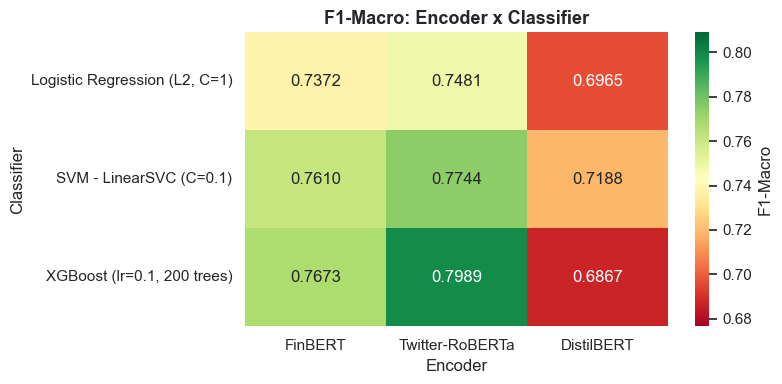

In [28]:
pivot = results_df.pivot(index='Model', columns='Encoder', values='F1-Macro')
# Reorder for consistent reading
pivot = pivot[['FinBERT', 'Twitter-RoBERTa', 'DistilBERT']]
pivot = pivot.reindex(['Logistic Regression (L2, C=1)',
                       'SVM - LinearSVC (C=0.1)',
                       'XGBoost (lr=0.1, 200 trees)'])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
            cbar_kws={'label': 'F1-Macro'},
            vmin=pivot.values.min() - 0.01,
            vmax=pivot.values.max() + 0.01,
            ax=ax)
ax.set_title('F1-Macro: Encoder x Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Encoder')
ax.set_ylabel('Classifier')
plt.tight_layout()
plt.show()

### 5.3 Comparison vs Notebook 04 Baselines

The strongest baseline from notebook 04 was **LinearSVC (C=0.1) on BoW Binary (stem) with F1-Macro 0.7603**. Did any transformer-encoder combination beat it?

In [ ]:
# Load the best traditional ML result from notebook 04 instead of hardcoding it.
ml_results_path = '../results/traditional_ml/ml_results.csv'
if os.path.exists(ml_results_path):
    ml_results  = pd.read_csv(ml_results_path)
    dl_keywords = ['RNN', 'BiRNN', 'LSTM']
    best_ml = ml_results.loc[
        ~ml_results['Model'].apply(lambda m: any(k in m for k in dl_keywords))
    ].sort_values('F1-Macro', ascending=False).iloc[0]
    TRADITIONAL_BEST = best_ml['F1-Macro']
else:
    # Fallback: SVM - LinearSVC (C=0.1) + BoW Binary (stem), captured from notebook 04
    # (../results/traditional_ml/ml_results.csv not generated yet)
    TRADITIONAL_BEST = 0.7603

best_transformer = results_df.iloc[0]
delta = best_transformer['F1-Macro'] - TRADITIONAL_BEST

fig, ax = plt.subplots(figsize=(11, 5))

# Build the comparison bar set
labels = ['Best Traditional ML\n(LinearSVC + BoW Binary stem)'] + \
         [f'{row.Model}\n+ {row.Encoder}' for _, row in results_df.iterrows()]
values = [TRADITIONAL_BEST] + results_df['F1-Macro'].tolist()
colors = ['#5b8db8'] + ['#2ecc71' if v > TRADITIONAL_BEST else '#c0392b' for v in results_df['F1-Macro']]

bars = ax.barh(labels, values, color=colors, edgecolor='white')
ax.axvline(TRADITIONAL_BEST, color='#5b8db8', linestyle='--', alpha=0.7,
           label=f'Traditional ML best ({TRADITIONAL_BEST:.4f})')

for bar, val in zip(bars, values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.invert_yaxis()
ax.set_xlim(0, 1.0)
ax.set_xlabel('F1-Macro')
ax.set_title(f'Transformer Encoders vs Traditional ML Baseline (delta = {delta:+.4f})',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'\nBest transformer combination : {best_transformer.Model} + {best_transformer.Encoder}')
print(f'  F1-Macro: {best_transformer["F1-Macro"]:.4f}')
print(f'  Delta vs traditional ML best: {delta:+.4f}')

### 5.4 Per-Class Recall - Are Transformers More Balanced?

A central question from notebook 04 was whether models inflate accuracy by over-predicting Neutral. Transformer encoders, trained on Twitter and financial text, should in principle be more sensitive to Bearish/Bullish signals than generic BoW representations - this is the place to check.

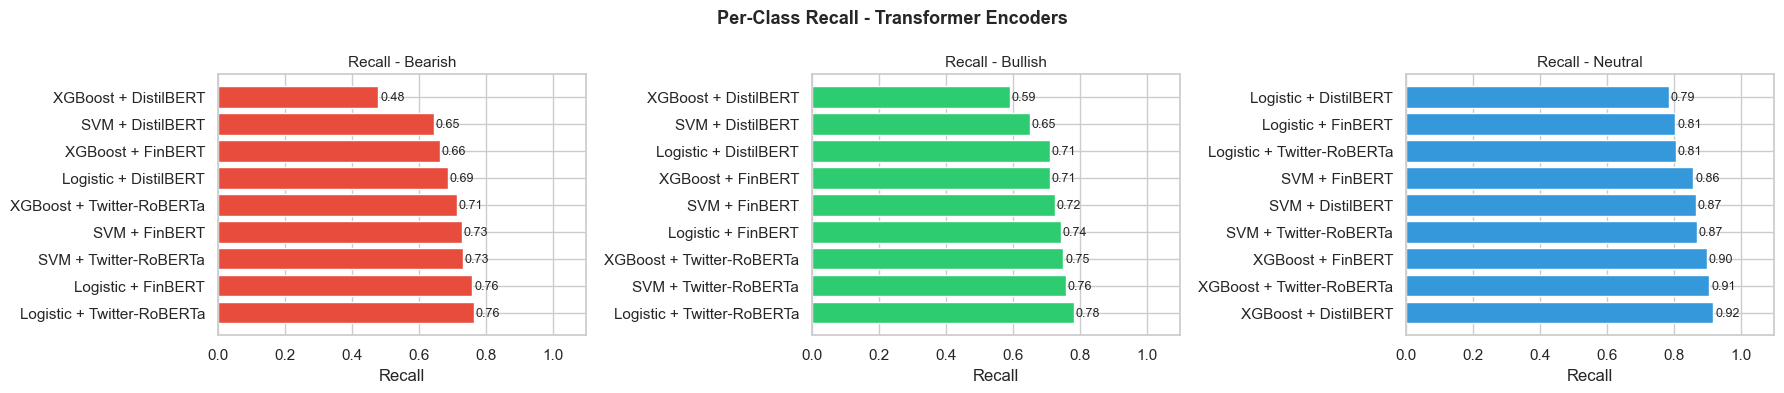

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, cls, color in zip(axes,
                           ['Bearish', 'Bullish', 'Neutral'],
                           ['#e74c3c', '#2ecc71', '#3498db']):
    col = f'R-{cls}'
    sub = results_df.sort_values(col, ascending=False)
    labels = [f'{row.Model.split()[0]} + {row.Encoder}' for _, row in sub.iterrows()]
    bars = ax.barh(labels, sub[col], color=color, edgecolor='white')
    for bar, val in zip(bars, sub[col]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)
    ax.set_title(f'Recall - {cls}', fontsize=11)
    ax.set_xlabel('Recall')
    ax.set_xlim(0, 1.1)

plt.suptitle('Per-Class Recall - Transformer Encoders', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Best per Encoder

In [31]:
best_per_encoder = (results_df
                    .sort_values('F1-Macro', ascending=False)
                    .groupby('Encoder', as_index=False)
                    .first()
                    .sort_values('F1-Macro', ascending=False)
                    .reset_index(drop=True))

print('Best classifier per encoder:\n')
print(best_per_encoder[['Encoder', 'Model', 'F1-Macro', 'Accuracy',
                        'R-Bearish', 'R-Bullish', 'R-Neutral']].to_string(index=False))

Best classifier per encoder:

        Encoder                       Model  F1-Macro  Accuracy  R-Bearish  R-Bullish  R-Neutral
Twitter-RoBERTa XGBoost (lr=0.1, 200 trees)    0.7989    0.8465      0.715      0.751      0.907
        FinBERT XGBoost (lr=0.1, 200 trees)    0.7673    0.8266      0.663      0.712      0.900
     DistilBERT     SVM - LinearSVC (C=0.1)    0.7188    0.7905      0.646      0.652      0.867


<div id="6-save" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">6. Save Embeddings & Results</h2>
</div>

Embeddings are saved so they can be reused (this is the expensive step - extraction takes ~5-10 min per encoder on GPU). The results table is saved for cross-notebook comparison in the final evaluation.

In [ ]:
os.makedirs('../results', exist_ok=True)
os.makedirs('../results/embeddings', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)


# Save embeddings - one pickle per encoder for modularity
transformer_features = {
    'finbert': {
        'X_train': X_train_finbert,
        'X_val'  : X_val_finbert,
        'X_test' : X_test_finbert,
    },
    'twitter_roberta': {
        'X_train': X_train_twitter,
        'X_val'  : X_val_twitter,
        'X_test' : X_test_twitter,
    },
    'distilbert': {
        'X_train': X_train_distil,
        'X_val'  : X_val_distil,
        'X_test' : X_test_distil,
    },
}

with open('../data/transformer_embeddings.pkl', 'wb') as f:
    pickle.dump(transformer_features, f)
print(f'Saved transformer embeddings -> ../data/transformer_embeddings.pkl')

# Save results
results_df.to_csv('../results/embeddings/transformer_embedding_results.csv', index=False)
results_df.to_pickle('../results/embeddings/transformer_embedding_results.pkl')
print(f'Saved {len(results_df)} results -> ../results/embeddings/transformer_embedding_results.pkl')

# Refit the best XGBoost (Twitter-RoBERTa embeddings, section 4.3) and persist it for notebook 09.
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.1,
                        objective='multi:softprob', num_class=3,
                        tree_method='hist', n_jobs=-1,
                        random_state=SEED, verbosity=0)

sw = compute_sample_weight('balanced', y_train)
xgb_clf.fit(X_train_twitter, y_train, sample_weight=sw)

os.makedirs('../results/models', exist_ok=True)
XGB_PATH = '../results/models/xgb_roberta_best.pkl'
with open(XGB_PATH, 'wb') as f:
    pickle.dump(xgb_clf, f)

print(f'Saved XGBoost (Twitter-RoBERTa) -> {XGB_PATH}')

Saved transformer embeddings -> ../data/transformer_embeddings.pkl
Saved 9 results -> ../results/embeddings/transformer_embedding_results.pkl
Saved XGBoost (Twitter-RoBERTa) -> ../results/models/xgb_roberta_best.pkl
